## Importing  Libraries

In [65]:
import pandas as pd
import numpy as np
import json
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import re

warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


## Importing Datasets

In [66]:
# Load modules.csv for analysis
# Ensure the file path is correct
modules_path = Path(r"C:\Users\matth\Downloads\problem2\data\modules.csv")
if not modules_path.exists():
    raise FileNotFoundError(f'Modules file not found: {modules_path.resolve()}')

modules_df = pd.read_csv(modules_path)

# Display basic info
print(f"Dataset shape: {modules_df.shape}")
print(f"\nColumns: {list(modules_df.columns)}")
modules_df.head()


Dataset shape: (7015, 14)

Columns: ['moduleCode', 'title', 'acadYear', 'faculty', 'department', 'moduleCredit', 'description', 'additionalInformation', 'workload', 'gradingBasisDescription', 'preclusion', 'prerequisite', 'corequisite', 'semestersOffered']


,moduleCode,title,acadYear,faculty,department,moduleCredit,description,additionalInformation,workload,gradingBasisDescription,preclusion,prerequisite,corequisite,semestersOffered
0,ABM5001,Leadership in Biomedicine,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,Leadership is fundamental to the success of in...,NaN,3/0/0/4/3,Graded,NaN,NaN,NaN,2
1,ABM5002,Advanced Biostatistics for Research,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,This course is served as a concept-based intro...,NaN,1.5/0.5/0/0/3,Graded,NaN,NaN,NaN,2
2,ABM5003,Biomedical Innovation & Enterprise,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,This course will furnish students with a thoro...,NaN,1.5/1.5/0/3/4,Graded,NaN,NaN,NaN,1
3,ABM5004,Capstone Project,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,8.0,This course encompasses research projects rele...,NaN,0/0/18/2/0,Graded,NaN,NaN,NaN,"1,2"
4,ABM5101,Applied Immunology,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,Advanced immunological applications play impor...,NaN,2/2.5/0/1/4.5,Graded,NaN,NaN,NaN,1


### EDA: Module Catalogue

This section profiles the module dataset, checks data quality, and inspects whether descriptions contain usable skill signals.


In [67]:
# High-level dataset profile
profile = pd.DataFrame({
    'dtype': modules_df.dtypes.astype(str),
    'non_null_count': modules_df.notna().sum(),
    'missing_count': modules_df.isna().sum(),
    'missing_pct': (modules_df.isna().mean() * 100).round(2),
    'n_unique': modules_df.nunique(dropna=True)
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])
profile


,dtype,non_null_count,missing_count,missing_pct,n_unique
additionalInformation,str,89,6926,98.73,61
corequisite,str,105,6910,98.50,81
prerequisite,str,2969,4046,57.68,2172
preclusion,str,3038,3977,56.69,2827
workload,str,6804,211,3.01,949
description,str,6868,147,2.10,5403
moduleCode,str,7015,0,0.00,7015
title,str,7015,0,0.00,5181
department,str,7015,0,0.00,92
moduleCredit,float64,7015,0,0.00,27


#### Missingness And Structural Balance


,missing_count,missing_pct
additionalInformation,6926,98.73%
corequisite,6910,98.50%
prerequisite,4046,57.68%
preclusion,3977,56.69%
workload,211,3.01%
description,147,2.10%


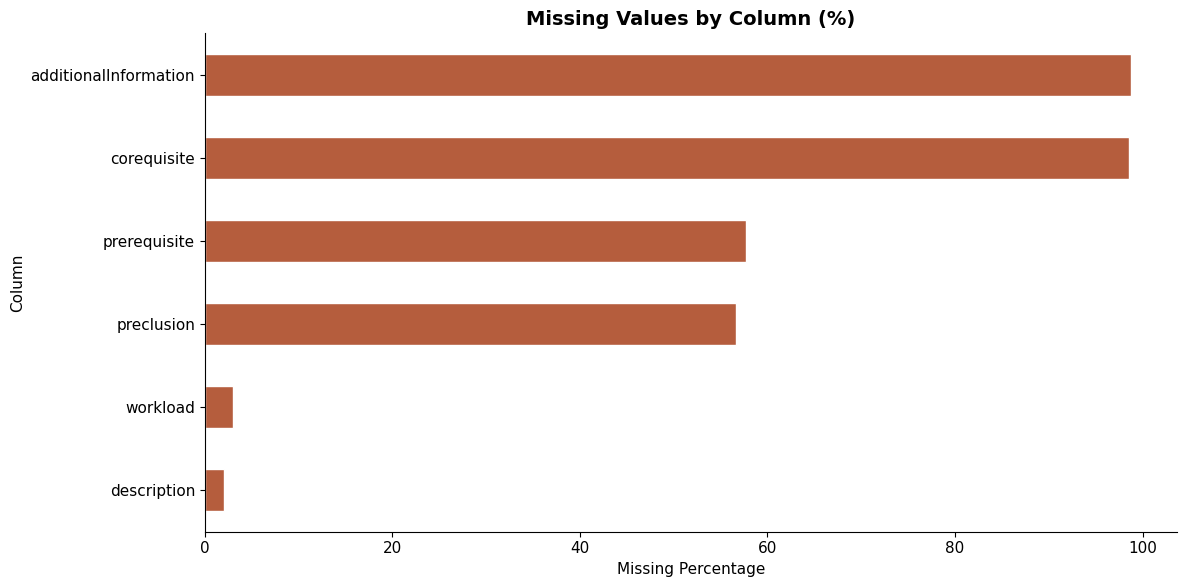

In [68]:
missing_summary = profile.loc[profile['missing_count'] > 0, ['missing_count', 'missing_pct']]

if missing_summary.empty:
    print('No missing values detected in modules_df.')
else:
    display(missing_summary.style.format({'missing_pct': '{:.2f}%'}))
    ax = missing_summary.sort_values('missing_pct').plot(
        kind='barh', y='missing_pct', legend=False, color='#b55d3d', edgecolor='white'
    )
    ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing Percentage')
    ax.set_ylabel('Column')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


#### Duplicate Checks On Useful Keys


In [69]:
exact_duplicates = modules_df.duplicated().sum()
print(f'Exact duplicate rows: {exact_duplicates}')

key_candidates = [c for c in modules_df.columns if any(token in c.lower() for token in ['code', 'id', 'title', 'name'])]
duplicate_checks = []

for col in key_candidates:
    dup_count = modules_df[col].duplicated().sum()
    duplicate_checks.append({
        'column': col,
        'duplicated_values': int(dup_count),
        'unique_values': int(modules_df[col].nunique(dropna=True))
    })

if duplicate_checks:
    display(pd.DataFrame(duplicate_checks).sort_values('duplicated_values', ascending=False))
else:
    print('No obvious code/id/title columns detected for duplicate-key checks.')


Exact duplicate rows: 0


,column,duplicated_values,unique_values
1,title,1834,5181
0,moduleCode,0,7015


#### Category Balance


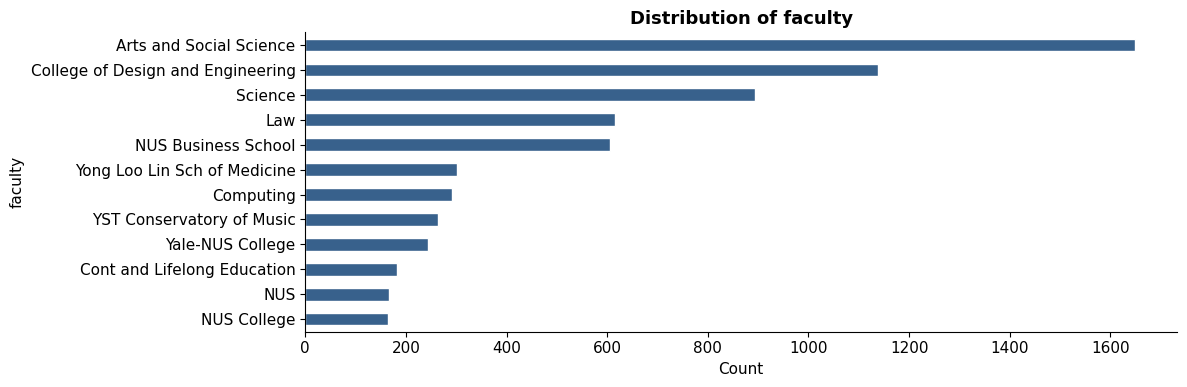

In [70]:
plot_columns = [c for c in ['faculty'] if c in modules_df.columns]

if not plot_columns:
    print('No low-cardinality categorical columns found to visualize.')
else:
    fig, axes = plt.subplots(len(plot_columns), 1, figsize=(12, 4 * len(plot_columns)))
    if len(plot_columns) == 1:
        axes = [axes]

    palette = ['#38618c', '#4e7a32', '#9a6228', '#7d4e91']
    for ax, col, color in zip(axes, plot_columns, palette):
        counts = modules_df[col].fillna('Missing').value_counts().head(12).sort_values()
        counts.plot(kind='barh', ax=ax, color=color, edgecolor='white')
        ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Count')
        ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


#### Description Quality And Noise


Using text column for EDA: description


,metric,count
0,Modules with missing descriptions,285
1,Missing-description modules inferred as semina...,93
2,Missing-description modules kept and filled wi...,192


,moduleCode,title,faculty,inferred_type
3956,LSM3288,Advanced UROPS in Life Sciences I,Science,seminar_or_project_like
3958,LSM3289,Advanced UROPS in Life Sciences II,Science,seminar_or_project_like
1242,CP4101,B.Comp. Dissertation,Computing,seminar_or_project_like
1069,CM2289,Basic UROPS In Chemistry II,Science,seminar_or_project_like
1067,CM2288,Basic UROPS in Chemistry I,Science,seminar_or_project_like
3907,LSM2288,Basic UROPS in Life Sciences I,Science,seminar_or_project_like
3909,LSM2289,Basic UROPS in Life Sciences II,Science,seminar_or_project_like
1427,DBA5102,Business Analytics Capstone Project,NUS Business School,seminar_or_project_like
623,BPS5000,Dissertation,College of Design and Engineering,seminar_or_project_like
619,BN6999,Doctoral Seminars,College of Design and Engineering,seminar_or_project_like


,count,mean,std,min,25%,50%,75%,max
char_count,6922.0,560.087691,219.630729,8.0,436.0,595.0,682.0,2120.0
word_count,6922.0,80.252095,31.601279,1.0,62.0,87.0,98.0,300.0


Rows removed from description analysis: 93
Rows using title as fallback description: 192


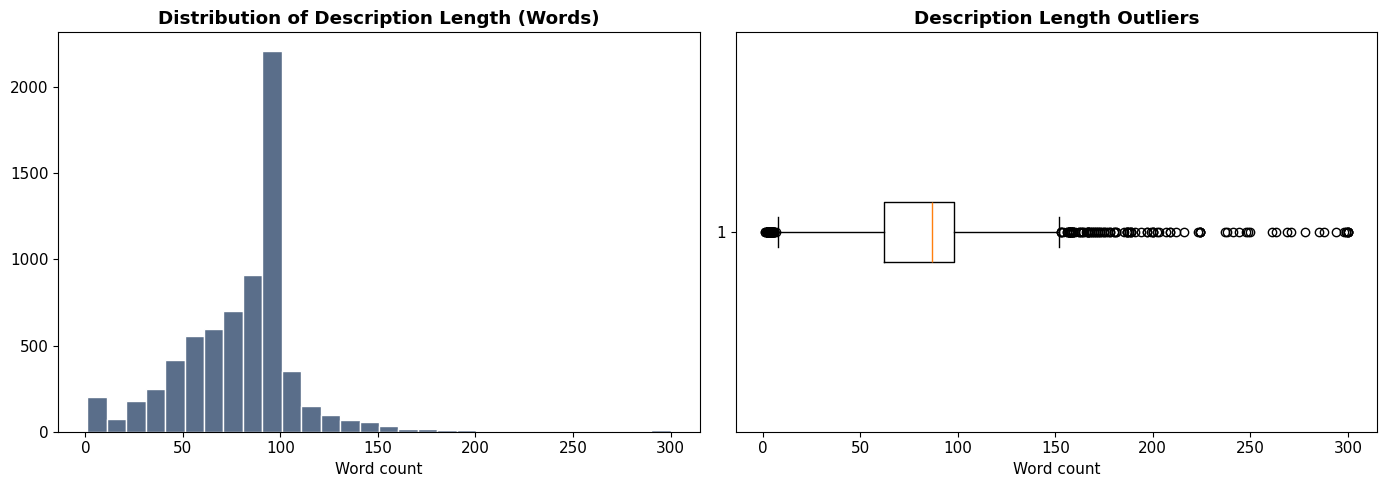

,moduleCode,title,description_for_eda
287,BMA5112A,Topics in Asian Business Environment,Topics in Asian Business Environment
299,BMA5302A,Investment Analysis & Management,Investment Analysis & Management
302,BMA5313A,Valuation and Mergers & Acquisitions,Valuation and Mergers & Acquisitions
323,BMA5524,Marketing Analytics,Marketing Analytics
324,BMA5528,Business to Business Marketing,Business to Business Marketing
699,BZD6011,Advanced Quantitative Research Methods,Advanced Quantitative Research Methods
815,CE5203,Traffic Flow & Control,Traffic Flow & Control
1286,CS2309,CS Research Methodology,CS Research Methodology
1440,DEP5101,Urban Analysis Workshop,Urban Analysis Workshop
1445,DEP5105,Urban Infrastructure and Mobility Systems,Urban Infrastructure and Mobility Systems


,moduleCode,title,faculty,description
0,ABM5001,Leadership in Biomedicine,Yong Loo Lin Sch of Medicine,Leadership is fundamental to the success of in...
1,ABM5002,Advanced Biostatistics for Research,Yong Loo Lin Sch of Medicine,This course is served as a concept-based intro...
2,ABM5003,Biomedical Innovation & Enterprise,Yong Loo Lin Sch of Medicine,This course will furnish students with a thoro...
3,ABM5004,Capstone Project,Yong Loo Lin Sch of Medicine,This course encompasses research projects rele...
4,ABM5101,Applied Immunology,Yong Loo Lin Sch of Medicine,Advanced immunological applications play impor...
5,ABM5102,Vaccine development and its modern applications,Yong Loo Lin Sch of Medicine,Use of vaccines and successful immunization ha...
6,ABM5103,Advanced technologies in immune therapeutic de...,Yong Loo Lin Sch of Medicine,The advancement of technologies for immune sys...
7,ABM5104,Microbiome-Aging-Immunity crosstalk,Yong Loo Lin Sch of Medicine,The complex relationship between human microbi...
8,ABM5105,Drugs used in Infectious Diseases,Yong Loo Lin Sch of Medicine,This course imparts students on the knowledge ...
9,ABM5106,Anticancer Therapeutics,Yong Loo Lin Sch of Medicine,This course will introduce different classes o...


In [71]:
description_col = 'description'
title_col = 'title'
module_code_col = 'moduleCode'
print(f'Using text column for EDA: {description_col}')

modules_eda = modules_df[[module_code_col, title_col, 'faculty', description_col]].copy()
raw_desc = modules_eda[description_col].fillna('').astype(str).str.strip()
invalid_desc_values = {'', 'nan', 'none', 'not available', 'n/a'}
blank_desc_mask = raw_desc.str.lower().isin(invalid_desc_values)

seminar_project_keywords = [
    'seminar', 'project', 'thesis', 'dissertation', 'capstone',
    'internship', 'attachment', 'practicum', 'independent study',
    'independent work', 'urops', 'research opportunities programme',
    'honours thesis', 'honors thesis'
]
title_pattern = '|'.join(re.escape(keyword) for keyword in seminar_project_keywords)
seminar_project_mask = modules_eda[title_col].fillna('').str.lower().str.contains(title_pattern, regex=True)

missing_desc_modules = modules_eda.loc[blank_desc_mask].copy()
missing_desc_modules['inferred_type'] = np.where(
    seminar_project_mask.loc[blank_desc_mask],
    'seminar_or_project_like',
    'use_title_as_fallback'
)

display(
    pd.DataFrame({
        'metric': [
            'Modules with missing descriptions',
            'Missing-description modules inferred as seminar/project-like',
            'Missing-description modules kept and filled with title'
        ],
        'count': [
            int(blank_desc_mask.sum()),
            int((blank_desc_mask & seminar_project_mask).sum()),
            int((blank_desc_mask & ~seminar_project_mask).sum())
        ]
    })
)

display(
    missing_desc_modules[[module_code_col, title_col, 'faculty', 'inferred_type']]
        .sort_values(['inferred_type', title_col])
        .head(20)
)

modules_eda['description_for_eda'] = raw_desc
modules_eda.loc[blank_desc_mask & ~seminar_project_mask, 'description_for_eda'] = modules_eda.loc[
    blank_desc_mask & ~seminar_project_mask,
    title_col
]

analysis_mask = ~(blank_desc_mask & seminar_project_mask)
analysis_modules = modules_eda.loc[analysis_mask].copy()
text_series = analysis_modules['description_for_eda']

desc_stats = pd.DataFrame({
    'char_count': text_series.str.len(),
    'word_count': text_series.str.split().str.len(),
    'used_title_as_fallback': analysis_modules['description_for_eda'].eq(analysis_modules[title_col])
})
display(desc_stats.describe().T)
print(f"Rows removed from description analysis: {(blank_desc_mask & seminar_project_mask).sum()}")
print(f"Rows using title as fallback description: {(blank_desc_mask & ~seminar_project_mask).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(desc_stats['word_count'], bins=30, color='#5a6e8a', edgecolor='white')
axes[0].set_title('Distribution of Description Length (Words)', fontweight='bold')
axes[0].set_xlabel('Word count')
axes[1].boxplot(desc_stats['word_count'], vert=False)
axes[1].set_title('Description Length Outliers', fontweight='bold')
axes[1].set_xlabel('Word count')
plt.tight_layout()
plt.show()

short_examples = analysis_modules.loc[
    desc_stats['word_count'] <= 5,
    [module_code_col, title_col, 'description_for_eda']
].head(10)
display(short_examples)

cleaned_modules_df = analysis_modules[[module_code_col, title_col, 'faculty', 'description_for_eda']].rename(
    columns={'description_for_eda': 'description'}
)
display(cleaned_modules_df.head(20))


#### Module Composition Visuals

These visuals show how concentrated the module catalogue is by faculty and how often fallback descriptions were needed after cleaning.


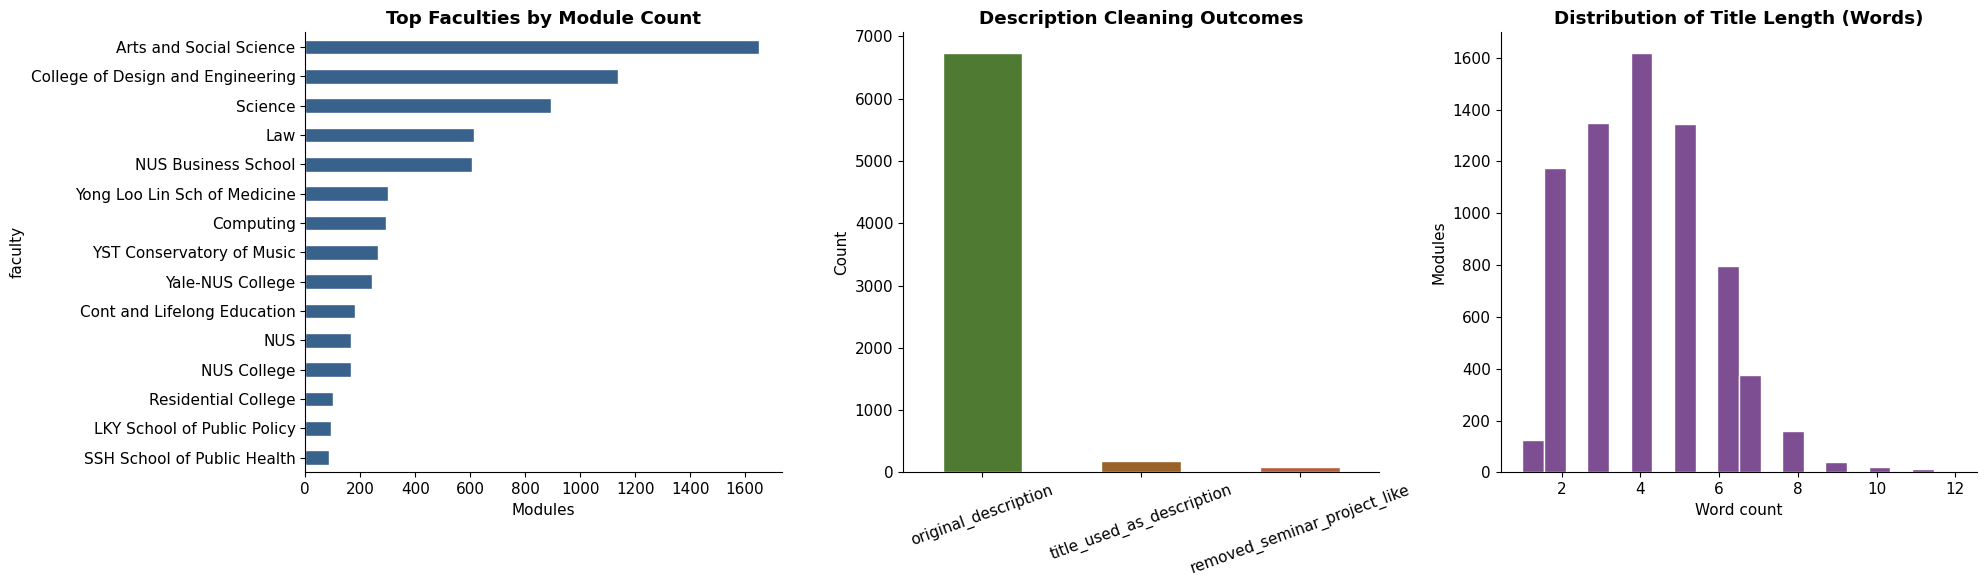

In [72]:
faculty_counts = modules_df['faculty'].fillna('Missing').value_counts().head(15).sort_values()
fallback_counts = pd.Series({
    'original_description': int((~blank_desc_mask).sum()),
    'title_used_as_description': int((blank_desc_mask & ~seminar_project_mask).sum()),
    'removed_seminar_project_like': int((blank_desc_mask & seminar_project_mask).sum())
})
title_word_counts = modules_df['title'].fillna('').astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
faculty_counts.plot(kind='barh', ax=axes[0], color='#38618c', edgecolor='white')
axes[0].set_title('Top Faculties by Module Count', fontweight='bold')
axes[0].set_xlabel('Modules')

fallback_counts.plot(kind='bar', ax=axes[1], color=['#4e7a32', '#9a6228', '#b55d3d'], edgecolor='white')
axes[1].set_title('Description Cleaning Outcomes', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

axes[2].hist(title_word_counts, bins=20, color='#7d4e91', edgecolor='white')
axes[2].set_title('Distribution of Title Length (Words)', fontweight='bold')
axes[2].set_xlabel('Word count')
axes[2].set_ylabel('Modules')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### EDA: Job Ads Dataset

This section combines all job-ad files from your local data folder, excluding `modules.csv`, and then profiles the combined dataset.


In [73]:
# Load data for job ads from the local data folder
job_ads = Path(r'C:\Users\matth\Downloads\problem2\data')
print(f'Reading data from: {job_ads.resolve()}')


Reading data from: C:\Users\matth\Downloads\problem2\data


In [74]:
def load_jobs(folder):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f'Folder not found: {folder.resolve()}')

    job_files = [p for p in sorted(folder.iterdir()) if p.is_file() and p.name.lower() != 'modules.csv']
    jobs = []
    skipped_files = []

    for filepath in job_files:
        try:
            if filepath.suffix.lower() == '.json':
                with open(filepath, 'r', encoding='utf-8') as f:
                    content = json.load(f)
                if isinstance(content, list):
                    jobs.extend(content)
                else:
                    jobs.append(content)
            else:
                skipped_files.append(filepath.name)
        except Exception as e:
            skipped_files.append(f'{filepath.name} ({e})')

    if not jobs:
        raise ValueError(f'No readable job ad files found in {folder.resolve()}')

    print(f'Total files scanned (excluding modules.csv): {len(job_files)}')
    print(f'Total job ads combined: {len(jobs)}')
    if skipped_files:
        print('Skipped files:')
        for name in skipped_files[:10]:
            print(f'  - {name}')
        if len(skipped_files) > 10:
            print(f'  ... and {len(skipped_files) - 10} more')
    return jobs

def extract_fields(jobs):
    rows = []
    for job in jobs:
        if not isinstance(job, dict):
            continue
        categories = [c.get('category', '').strip() for c in job.get('categories', []) if isinstance(c, dict) and c.get('category')]
        skills = [s.get('skill', '').strip().lower() for s in job.get('skills', []) if isinstance(s, dict) and s.get('skill')]
        emp_types = [e.get('employmentType', '').strip() for e in job.get('employmentTypes', []) if isinstance(e, dict) and e.get('employmentType')]
        positions = [p.get('position', '').strip() for p in job.get('positionLevels', []) if isinstance(p, dict) and p.get('position')]
        rows.append({
            'job_id': job.get('metadata', {}).get('jobPostId', 'N/A') if isinstance(job.get('metadata', {}), dict) else 'N/A',
            'title': job.get('title', 'Unknown'),
            'company': job.get('postedCompany', {}).get('name', 'Unknown') if isinstance(job.get('postedCompany', {}), dict) else 'Unknown',
            'categories': categories,
            'skills': skills,
            'employment_type': emp_types,
            'position_level': positions,
        })
    return pd.DataFrame(rows)

jobs = load_jobs(job_ads)
df = extract_fields(jobs)
df.head()


Total files scanned (excluding modules.csv): 22720
Total job ads combined: 22720


,job_id,title,company,categories,skills,employment_type,position_level
0,ATS-2026-0184172,"Assistant Manager, Corporate Communications",CITY DEVELOPMENTS LIMITED,[Marketing / Public Relations],"[multimedia, social media, strategic communica...",[Permanent],[Junior Executive]
1,ATS-2026-0190206,Manager (Facilities Management),NTUC FAIRPRICE CO-OPERATIVE LTD,[Real Estate / Property Management],"[fire safety, management skills, sustainabilit...",[Permanent],[Manager]
2,MCF-2025-1100407,Sales Administrator,THE FULLERTON HOTEL,"[Hospitality, Sales / Retail]","[sales, microsoft office, microsoft excel, tra...",[Full Time],[Executive]
3,MCF-2025-1103608,Assistant Field Engineer(Construction),"ENZAN KOUBOU CO., LTD. Singapore Branch","[Customer Service, Engineering, Professional S...","[troubleshooting, construction, hardware, elec...",[Full Time],[Fresh/entry level]
4,MCF-2025-1105270,Electronic Keyboard Teacher,SYMPHONY MUSIC SCHOOL,[Education and Training],"[piano, classical, microsoft excel, teaching, ...",[Full Time],[Non-executive]


In [75]:
df['category_count'] = df['categories'].apply(len)
df['skill_count'] = df['skills'].apply(len)
df['employment_type_count'] = df['employment_type'].apply(len)

summary = pd.DataFrame({
    'Metric': [
        'Total job postings', 'Unique job titles', 'Unique companies', 'Unique categories',
        'Total skill tags', 'Unique skills', 'Median skills per job', 'Jobs without tagged skills'
    ],
    'Value': [
        len(df),
        df['title'].nunique(),
        df['company'].nunique(),
        pd.Series([c for lst in df['categories'] for c in lst]).nunique(),
        int(df['skill_count'].sum()),
        pd.Series([s for lst in df['skills'] for s in lst]).nunique(),
        float(df['skill_count'].median()),
        int((df['skill_count'] == 0).sum())
    ]
})
summary


,Metric,Value
0,Total job postings,22720.0
1,Unique job titles,14996.0
2,Unique companies,5377.0
3,Unique categories,43.0
4,Total skill tags,334729.0
5,Unique skills,9491.0
6,Median skills per job,15.0
7,Jobs without tagged skills,0.0


In [76]:
duplicate_compare_cols = ['title', 'company', 'categories', 'skills']
duplicate_check_df = df.copy()
duplicate_check_df['categories_key'] = duplicate_check_df['categories'].apply(lambda x: tuple(sorted(x)) if isinstance(x, list) else tuple())
duplicate_check_df['skills_key'] = duplicate_check_df['skills'].apply(lambda x: tuple(sorted(x)) if isinstance(x, list) else tuple())
duplicate_groups = duplicate_check_df.groupby(['title', 'company', 'categories_key', 'skills_key'], dropna=False).agg(
    job_count=('job_id', 'size'),
    unique_job_ids=('job_id', lambda x: sorted(set(x))),
    unique_position_levels=('position_level', lambda x: sorted({tuple(v) if isinstance(v, list) else v for v in x})),
    unique_employment_types=('employment_type', lambda x: sorted({tuple(v) if isinstance(v, list) else v for v in x}))
).reset_index()
duplicate_groups = duplicate_groups[duplicate_groups['job_count'] > 1].sort_values('job_count', ascending=False)

duplicate_summary = pd.DataFrame({
    'metric': [
        'Potential duplicate job groups (ignoring job_id, position_level, employment_type)',
        'Total job rows involved in these duplicate groups'
    ],
    'count': [
        int(len(duplicate_groups)),
        int(duplicate_groups['job_count'].sum()) if not duplicate_groups.empty else 0
    ]
})
display(duplicate_summary)

if duplicate_groups.empty:
    print('No potential duplicate job ads found under this comparison rule.')
else:
    duplicate_display = duplicate_groups.copy()
    duplicate_display['categories'] = duplicate_display['categories_key'].apply(list)
    duplicate_display['skills'] = duplicate_display['skills_key'].apply(list)
    display(duplicate_display[['title', 'company', 'job_count', 'unique_job_ids', 'unique_position_levels', 'unique_employment_types', 'categories', 'skills']].head(20))


,metric,count
0,Potential duplicate job groups (ignoring job_i...,1435
1,Total job rows involved in these duplicate groups,5044


,title,company,job_count,unique_job_ids,unique_position_levels,unique_employment_types,categories,skills
16999,Supervisor,DING FENG INFORMATION SERVICES PTE. LTD.,107,"[MCF-2026-0163616, MCF-2026-0163628, MCF-2026-...","[(Professional,), (Senior Executive,)]","[(Contract,)]",[General Work],"[ability to learn, coaching, compliance, const..."
10243,Marketing and Sales Trainee (Entry Level),ROYAL ORG PTE. LTD.,47,"[MCF-2026-0152901, MCF-2026-0152906, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Marketing / Public Relations, Sales / Retail]","[ability to travel, coaching, communication sk..."
8759,Junior Sales and Marketing Representative,ROYAL ORG PTE. LTD.,35,"[MCF-2026-0152879, MCF-2026-0152883, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Marketing / Public Relations, Sales / Retail]","[ability to travel, coaching, communication sk..."
6199,Event and Marketing (Entry Level),MYTHIC VISION,23,"[MCF-2026-0164033, MCF-2026-0164051, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]",[Marketing / Public Relations],"[communication skills, customer acquisition, c..."
14180,SUPERVISOR,OCEANDA HR PTE. LTD.,22,"[MCF-2026-0160999, MCF-2026-0161044, MCF-2026-...","[(Professional,)]","[(Contract, Full Time)]",[General Work],"[ability to learn, coaching, compliance, const..."
10204,Marketing Trainee (No experience required),J&N VENTURES,22,"[MCF-2026-0154472, MCF-2026-0154476, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Events / Promotions, Marketing / Public Relat...","[brand communication, coaching, communication,..."
6885,Financial Consultant,LIONBROKERS PTE. LTD.,19,"[MCF-2026-0159375, MCF-2026-0159396, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Insurance, Sales / Retail]","[banking, coaching, corporate finance, entrepr..."
14314,Sales & Marketing (No experience required),J&N VENTURES,14,"[MCF-2026-0159511, MCF-2026-0159548, MCF-2026-...","[(Fresh/entry level,)]","[(Full Time,)]","[Events / Promotions, Marketing / Public Relat...","[b2c communication, brand communication, coach..."
10039,Marketing Brand Ambassador (Fun environment 🥳),ROYAL ORG PTE. LTD.,14,"[MCF-2025-1953784, MCF-2025-1970673, MCF-2025-...","[(Junior Executive,)]","[(Permanent, Full Time)]","[Education and Training, Events / Promotions, ...","[able to work independently, brand awareness, ..."
6769,Finance & Accounts Officer - WCAN,WECRUIT PTE. LTD.,13,"[MCF-2025-1773680, MCF-2025-1780927, MCF-2025-...","[(Senior Executive,)]","[(Permanent, Full Time)]",[Accounting / Auditing / Taxation],"[able to work independently, acca, account man..."


#### Job Ads Visual Deep Dive

These plots add more structure around company concentration, skills per job, and the size of potential duplicate-job groups.


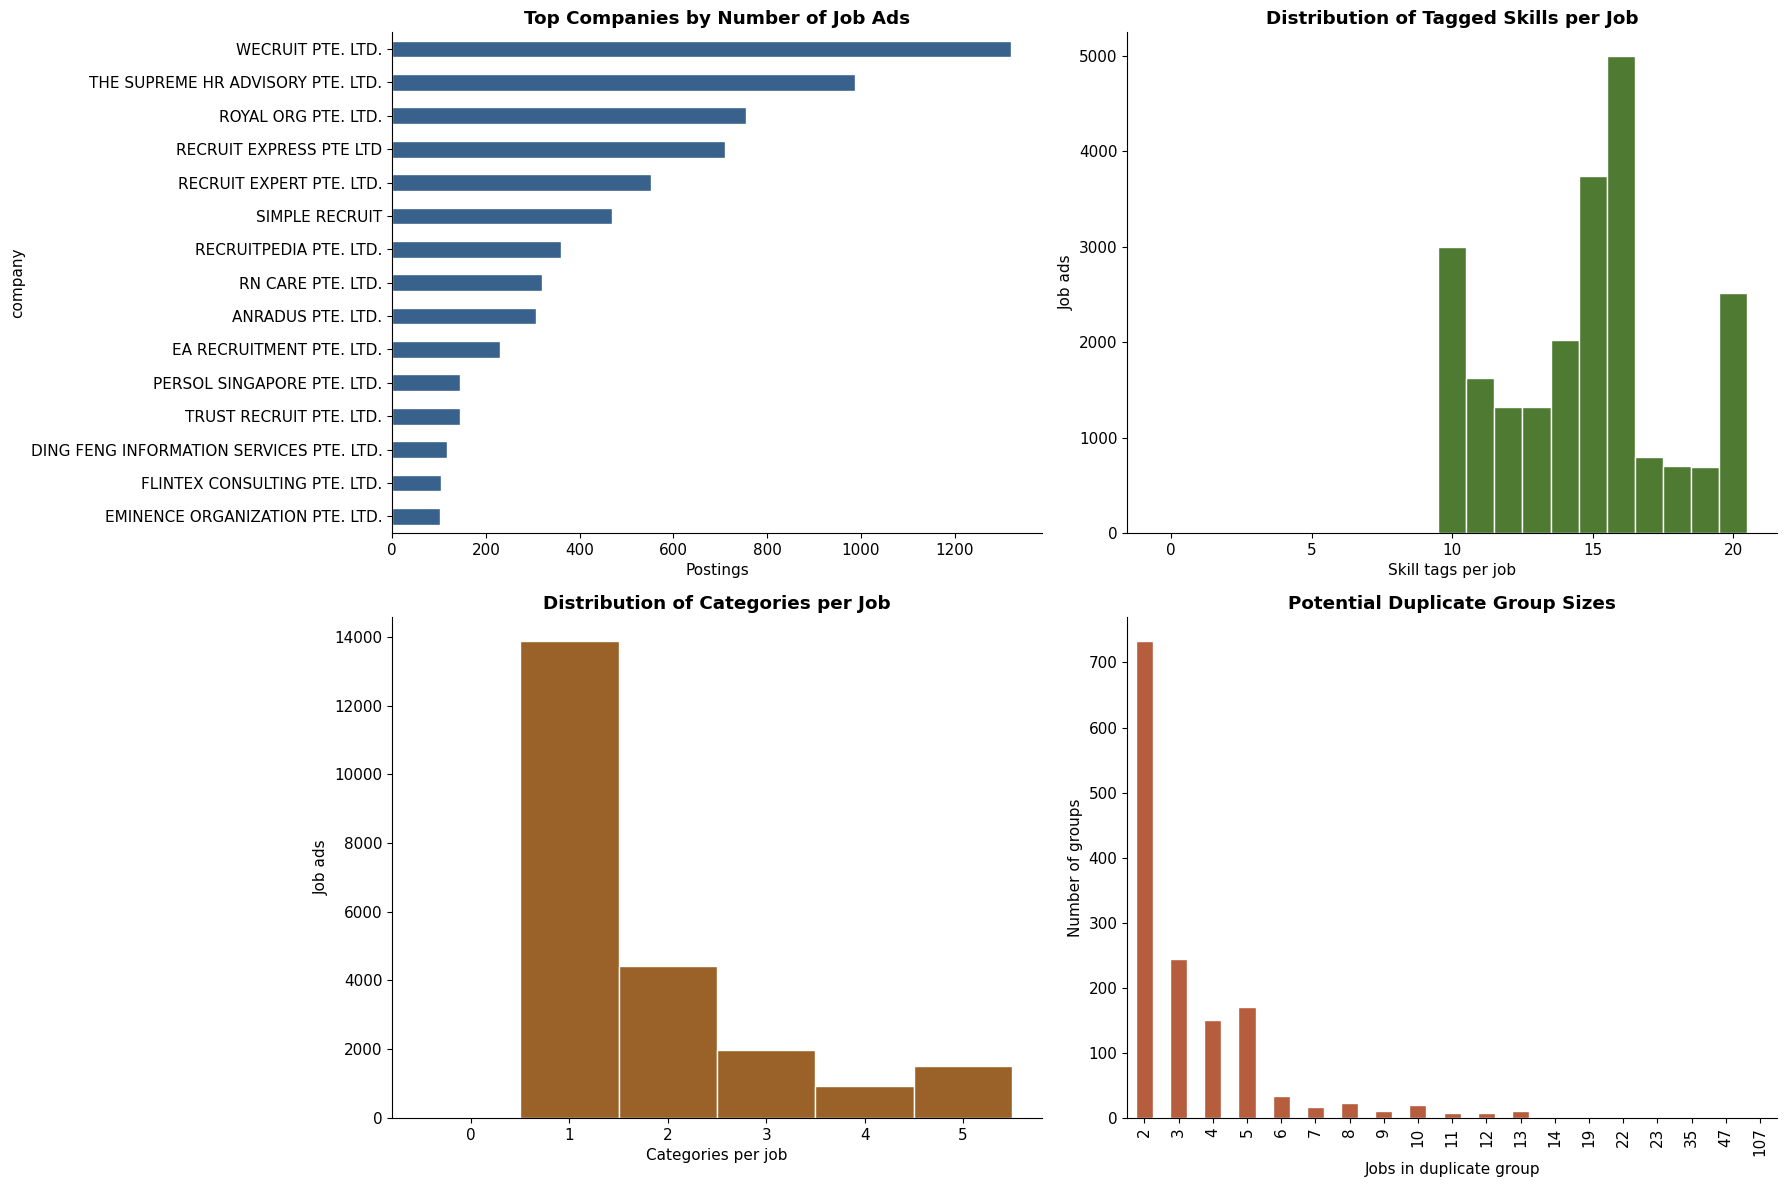

In [77]:
top_companies = df['company'].value_counts().head(15).sort_values()
duplicate_group_sizes = duplicate_groups['job_count'].value_counts().sort_index() if not duplicate_groups.empty else pd.Series(dtype='int64')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top_companies.plot(kind='barh', ax=axes[0, 0], color='#38618c', edgecolor='white')
axes[0, 0].set_title('Top Companies by Number of Job Ads', fontweight='bold')
axes[0, 0].set_xlabel('Postings')

axes[0, 1].hist(df['skill_count'], bins=range(0, int(df['skill_count'].max()) + 2), color='#4e7a32', edgecolor='white', align='left')
axes[0, 1].set_title('Distribution of Tagged Skills per Job', fontweight='bold')
axes[0, 1].set_xlabel('Skill tags per job')
axes[0, 1].set_ylabel('Job ads')

axes[1, 0].hist(df['category_count'], bins=range(0, int(df['category_count'].max()) + 2), color='#9a6228', edgecolor='white', align='left')
axes[1, 0].set_title('Distribution of Categories per Job', fontweight='bold')
axes[1, 0].set_xlabel('Categories per job')
axes[1, 0].set_ylabel('Job ads')

if duplicate_group_sizes.empty:
    axes[1, 1].text(0.5, 0.5, 'No duplicate groups found', ha='center', va='center')
    axes[1, 1].set_title('Potential Duplicate Group Sizes', fontweight='bold')
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])
else:
    duplicate_group_sizes.plot(kind='bar', ax=axes[1, 1], color='#b55d3d', edgecolor='white')
    axes[1, 1].set_title('Potential Duplicate Group Sizes', fontweight='bold')
    axes[1, 1].set_xlabel('Jobs in duplicate group')
    axes[1, 1].set_ylabel('Number of groups')

for ax in axes.flat:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


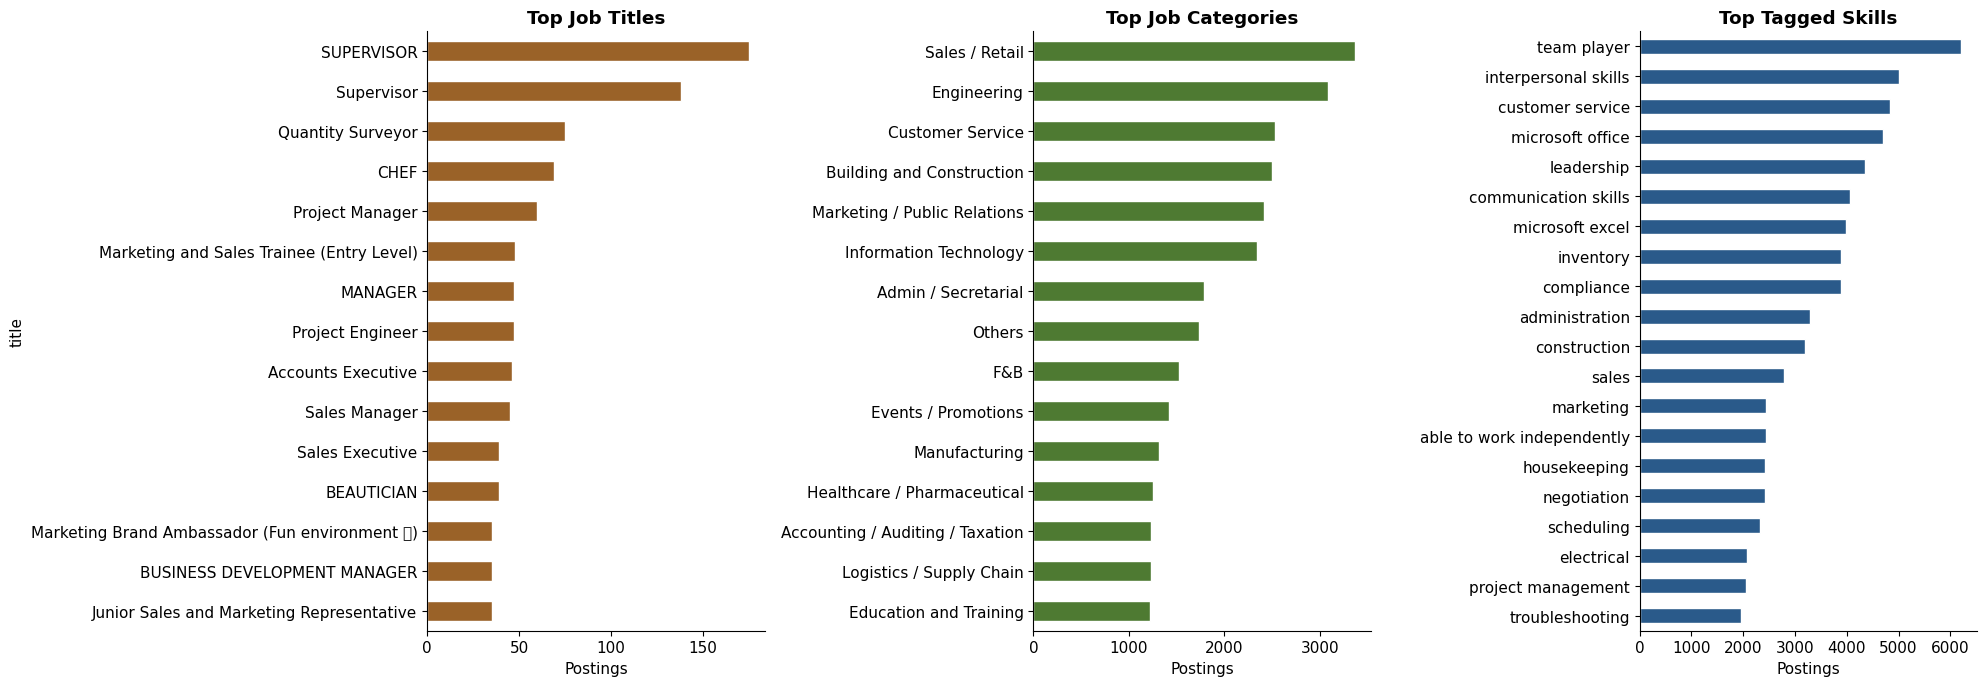

In [78]:
top_titles = df['title'].value_counts().head(15)
cat_counts = pd.Series([c for lst in df['categories'] for c in lst]).value_counts().head(15)
top_skills = pd.Series([s for lst in df['skills'] for s in lst]).value_counts().head(20)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
top_titles.sort_values().plot(kind='barh', ax=axes[0], color='#9a6228', edgecolor='white')
axes[0].set_title('Top Job Titles', fontweight='bold')
axes[0].set_xlabel('Postings')
cat_counts.sort_values().plot(kind='barh', ax=axes[1], color='#4e7a32', edgecolor='white')
axes[1].set_title('Top Job Categories', fontweight='bold')
axes[1].set_xlabel('Postings')
top_skills.sort_values().plot(kind='barh', ax=axes[2], color='#2a5a8a', edgecolor='white')
axes[2].set_title('Top Tagged Skills', fontweight='bold')
axes[2].set_xlabel('Postings')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
